# 🌟 Exercise 1 : Understanding Data Visualization

## Instructions

- Explain why data visualization is important in data analysis.
- Describe the purpose of a line graph in data visualization.

### Answer

Data visualization is essential in data analysis because it transforms complex, raw data into accessible, visual formats (charts, graphs, maps) that facilitate rapid, informed decision-making. It helps analysts immediately spot trends, patterns, and outliers, improves communication of insights, and supports exploratory data analysis by revealing data structures.

A line graph in data visualization is used to display, track, and analyze changes in continuous data over specific intervals of time or ordered categories


# 🌟 Exercise 2 : Creating a Line Plot for Temperature Variation

## Instructions

- Create a simple line plot using Matplotlib that represents the temperature variations over a week.
- Use a list of temperature values for each day of the week (e.g., [72, 74, 76, 80, 82, 78, 75]) and label the x-axis as “Day” and the y-axis as “Temperature (°F)”.

### Answer

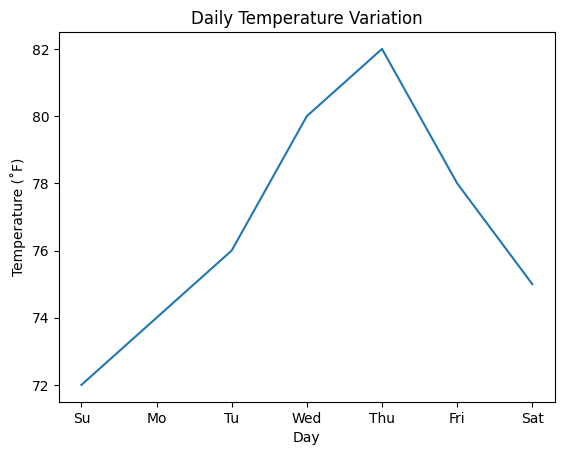

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

temperatures = [72, 74, 76, 80, 82, 78, 75]
days = ['Su', 'Mo', 'Tu', 'Wed', 'Thu', 'Fri', 'Sat']

ax.plot(days, temperatures)
ax.set_title('Daily Temperature Variation')
ax.set_xlabel('Day')
ax.set_ylabel('Temperature (˚F)')

plt.show()


# 🌟 Exercise 3 : Visualizing Monthly Sales with a Bar Chart

## Instructions

- Generate a bar chart using Matplotlib to visualize the monthly sales data for a retail store.
- Create a list of sales values for each month (e.g., [5000, 5500, 6200, 7000, 7500]) and label the x-axis as “Month” and the y-axis as “Sales Amount ($)”.

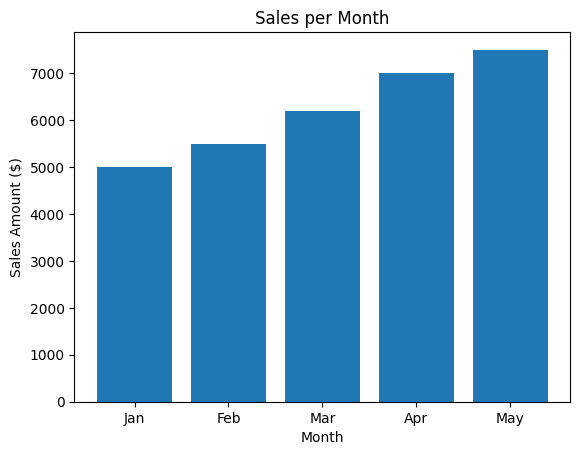

In [142]:
sales = [5000, 5500, 6200, 7000, 7500]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']

fig, ax = plt.subplots()

ax.bar(months, sales)
ax.set_title('Sales per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Sales Amount ($)')

plt.show()

# 🌟 Exercise 4 : Data Visualisation

## Instructions

Using the dataset: sales_data.csv

- Calculate the total quantity of products sold by the company.
- Identify the category that had the highest revenue and calculate how much revenue it generated.
- Determine the average revenue per sale in the dataset.
- Create a bar chart to visualize the total revenue generated in each quarter of the year (Q1, Q2, Q3, Q4).

In [143]:
# Basic workflow
df = pd.read_csv('data/sales_data.csv')

df.head()

,date,product,category,price,quantity,revenue
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0


In [144]:
df.shape

(369, 6)

In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      369 non-null    str    
 1   product   369 non-null    str    
 2   category  369 non-null    str    
 3   price     367 non-null    float64
 4   quantity  368 non-null    float64
 5   revenue   368 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.4 KB


In [146]:
df.describe()

,price,quantity,revenue
count,367.000000,368.000000,368.000000
mean,211.226158,14.565217,2060.679348
std,227.335170,8.595740,1910.930790
min,20.000000,3.000000,300.000000
25%,50.000000,8.000000,800.000000
50%,100.000000,12.000000,1200.000000
75%,300.000000,20.000000,2400.000000
max,1200.000000,50.000000,7200.000000


In [147]:
# Get total quantity of products sold
total_quantity_sold = df['quantity'].sum()
print(f"The total quantity of products sold was {int(total_quantity_sold)}.")

The total quantity of products sold was 5360.


In [148]:
# Check the unique values in the 'category' column
unique_values = df['category'].unique()
print('All unique values in the column category:')
print(unique_values)

All unique values in the column category:
<StringArray>
['Electronics',    'Clothing', 'Accessories',        'Bags',       'Shoes',
    'Clohting',        'Bgas',     'Shoeses']
Length: 8, dtype: str


In [149]:
# Define the mapping of wrong values to correct values
typo_mapping = {
    'Bgas': 'Bags',
    'Clohting': 'Clothing',
    'Shoeses': 'Shoes'
}

# Replace the misspelled values in the 'category' column
df['category'] = df['category'].replace(typo_mapping)

# Check if the misspelled values were substituted
new_unique_values = df['category'].unique()
print('New unique values in the column category:')
print(new_unique_values)

New unique values in the column category:
<StringArray>
['Electronics', 'Clothing', 'Accessories', 'Bags', 'Shoes']
Length: 5, dtype: str


In [150]:
# Group by 'category' and select only 'revenue' column
# Sum 'revenue' for each category
grouped_cat = df.groupby('category')['revenue'].sum()

print(grouped_cat)

# Get the row label of the highest value
highest_cat = grouped_cat.idxmax()

print(f"\nThe categoty of highest revenue is {highest_cat} and its total revenue is ${grouped_cat[highest_cat]}.")

category
Accessories    104700.0
Bags            20400.0
Clothing        95550.0
Electronics    516080.0
Shoes           21600.0
Name: revenue, dtype: float64

The categoty of highest revenue is Electronics and its total revenue is $516080.0.


In [151]:
# Get the mean of the revenue
mean = df['revenue'].mean()

print(f"The average revenue per sale is ${mean.round(2)}.")

The average revenue per sale is $2060.68.



Unique years present in the column:
[2022]
date
2022Q1    182100.0
2022Q2    183970.0
2022Q3    197680.0
2022Q4    194580.0
Freq: Q-DEC, Name: revenue, dtype: float64


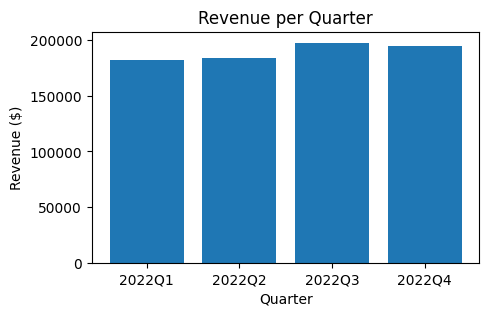

In [152]:
# Ensure the column is a datetime object
df['date'] = pd.to_datetime(df['date'])

# Extract the year component
# The .dt accessor is used to access datetime properties
years = df['date'].dt.year

# Find the unique year values
unique_years = years.unique()

print("\nUnique years present in the column:")
print(unique_years)

# Group revenue by quarter using the .dt accessor
grouped_by_date = df.groupby(df['date'].dt.to_period('Q'))['revenue'].sum()

print(grouped_by_date)

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(grouped_by_date.index.astype(str), grouped_by_date.values)
ax.set_title('Revenue per Quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Revenue ($)')

plt.show()


# 🌟 Exercise 5 : Data Visualisation Using MatPlotLib

## Instructions

- Create a simple line plot using Matplotlib. Plot the function y = x^2 for x values ranging from -10 to 10. Add a title and label the x and y axes.
- Generate a bar chart to display the sales data of four different products (A, B, C, D) in a week. The sales values are 15, 30, 45, and 20 respectively. Label the chart appropriately.
- Create a pie chart representing the following data about favorite fruits of a group of people: Apples (40%), Bananas (30%), Cherries (20%), and Dates (10%). Customize the chart with different colors for each fruit and add a legend.

### Answer

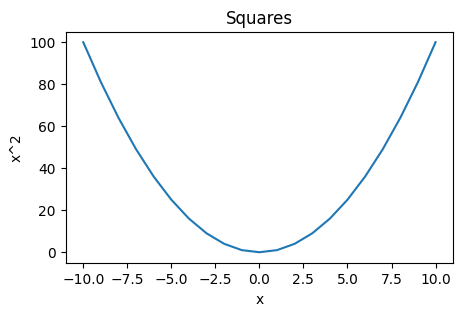

In [153]:
x_values = [x for x in range(-10, 11)]
y = [x*x for x in x_values]

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x_values, y)
ax.set_title('Squares')
ax.set_xlabel('x')
ax.set_ylabel('x^2')

plt.show()

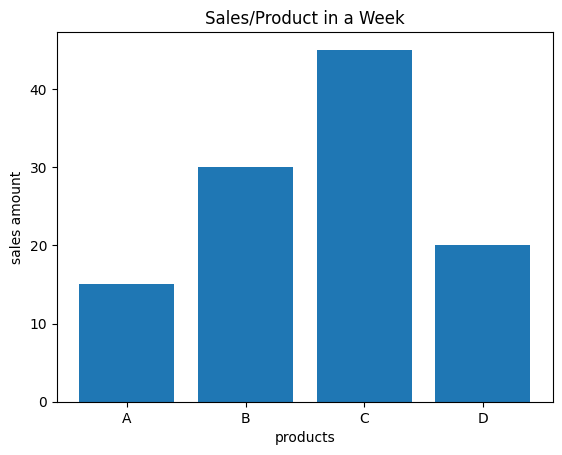

In [154]:
products = ['A', 'B', 'C', 'D']
sales = [15, 30, 45, 20]

fig, ax = plt.subplots()
ax.bar(products, sales)
ax.set_title('Sales/Product in a Week')
ax.set_xlabel('products')
ax.set_ylabel('sales amount')

plt.show()

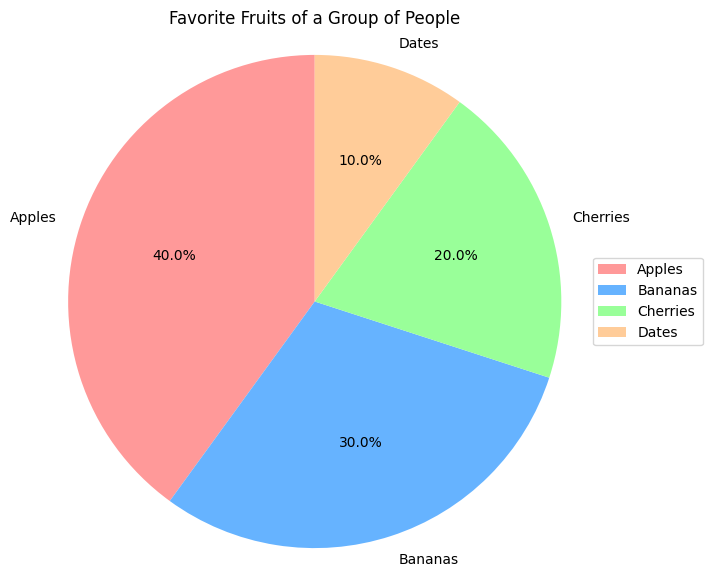

In [155]:
# 1. Create a pandas Series from the data
# The keys of the dictionary become the index (labels), and the values become the data
fruit_data = {'Apples': 40, 'Bananas': 30, 'Cherries': 20, 'Dates': 10}
s = pd.Series(fruit_data)

# 2. Define custom colors for each fruit
custom_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # Example hex colors

# 3. Create the pie chart using the pandas plot.pie() method
# The 'autopct' parameter adds percentage labels to the slices
# The 'colors' parameter applies the custom colors
# We use Matplotlib's 'ax' to add a legend easily
fig, ax = plt.subplots(figsize=(7, 7)) # Adjust figure size as needed
s.plot.pie(
    ax=ax,
    autopct='%1.1f%%',
    colors=custom_colors,
    startangle=90, # Start the first slice (Apples) at 90 degrees
    ylabel='' # Removes the default 'None' label from the center-left of the chart
)

# 4. Add a legend
# The legend labels are taken from the Series index
ax.legend(labels=s.index, loc='center left', bbox_to_anchor=(1, 0.5)) # Position the legend outside the chart

# 5. Add a title and ensure the chart is circular
plt.title('Favorite Fruits of a Group of People')
plt.axis('equal') # Ensures the pie chart is drawn as a perfect circle

# 6. Display the plot
plt.show()